In [37]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import ScalarFormatter

import pandas as pd
import numpy as np
import selfies as sf
from collections import Counter, defaultdict
from tqdm import tqdm
import json
from matplotlib.ticker import MultipleLocator
import os
import re
import pickle

In [3]:
COLORS = {
    "Other": "#0072B2",
    "Scenario 1": "#009E73",
    "Scenario 2": "#E69F00",
    "Scenario 3": "#CC79A7"
}

custom_style = {
    "font.size": 16,
    "axes.labelsize": 18,
    "axes.titlesize": 20,
    "legend.fontsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "lines.linewidth": 2.5,
    "lines.markersize": 8,
    "xtick.major.size": 7,
    "ytick.major.size": 7,
    "xtick.major.width": 2,
    "ytick.major.width": 2,
    "figure.titlesize": 22,
    "figure.dpi": 120,
    "figure.figsize": (7, 5),
    "legend.frameon": True,
    "legend.framealpha": 0.85,
    "legend.loc": 'best',
    "axes.grid": True,
    "grid.linewidth": 1.2,
    "grid.alpha": 0.4,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "svg.fonttype": "none",
    "savefig.format": "svg"
}
plt.rcParams.update(custom_style)

# Results

## Model Evaluation

### Top-k curves

In [ ]:
# Paths and settings
scenarios = [
    ("random",   {"dir": "scope_gen/de_novo_molecules/data/finetune-random/beam100",   "color": COLORS["Scenario 1"], "row_label": "Scenario (1)"}),
    ("mces1",    {"dir": "scope_gen/de_novo_molecules/data/finetune-mces1/beam100",    "color": COLORS["Scenario 2"], "row_label": "Scenario (2)"}),
    ("original", {"dir": "scope_gen/de_novo_molecules/data/finetune-original/beam100", "color": COLORS["Scenario 3"], "row_label": "Scenario (3)"}),
]

metrics = [
    ("tani", {"file": "tanimoto_sorted.npy", "file_unsorted": "tanimoto_unsorted.npy", "stat": "max"}),
    ("mces", {"file": "mces_sorted.npy",     "file_unsorted": "mces_unsorted.npy",     "stat": "min"}),
    ("acc",  {"file": "acc_sorted.npy",      "file_unsorted": "acc_unsorted.npy",      "stat": "max"}),
]

# 3 rows = metrics, 3 columns = scenarios
fig, axs = plt.subplots(3, 3, figsize=(18, 12), sharex="col")

# Scenario titles on top
for j, (_, sc_cfg) in enumerate(scenarios):
    axs[0, j].set_title(sc_cfg["row_label"], fontsize=22, fontweight="bold")

for i, (met_key, met_cfg) in enumerate(metrics):
    stat_fun = np.max if met_cfg["stat"] == "max" else np.min

    for j, (sc_key, sc_cfg) in enumerate(scenarios):
        ax = axs[i, j]

        fname_sorted = os.path.join(sc_cfg["dir"], met_cfg["file"])
        fname_unsorted = os.path.join(sc_cfg["dir"], met_cfg["file_unsorted"])

        try:
            arr_sorted = np.load(fname_sorted)
        except FileNotFoundError:
            print(f"File not found: {fname_sorted}, skipping.")
            ax.set_axis_off()
            continue

        try:
            arr_unsorted = np.load(fname_unsorted)
        except FileNotFoundError:
            print(f"File not found: {fname_unsorted}, using sorted values for Prob ranking.")
            arr_unsorted = arr_sorted.copy()

        topk_x = np.arange(1, arr_sorted.shape[1] + 1)

        y_sorted = [np.mean(stat_fun(arr_sorted[:, :k], axis=1)) for k in topk_x]
        y_unsorted = [np.mean(stat_fun(arr_unsorted[:, :k], axis=1)) for k in topk_x]

        ax.plot(topk_x, y_sorted, color=sc_cfg["color"], linewidth=3)
        ax.plot(topk_x, y_unsorted, "--", color=sc_cfg["color"], linewidth=3)

        if i == 2:
            ax.set_xlabel("Top-k", fontsize=20)
            ax.tick_params(axis="x", labelbottom=True, labelsize=16)
        else:
            ax.set_xlabel("")
            ax.tick_params(axis="x", labelbottom=False)

        ax.set_ylabel("")
        ax.tick_params(axis="y", labelsize=16)
        ax.grid(True, axis="y", alpha=0.25)

# Centered row labels using figure coordinates
fig.text(0.03, 0.78, "Tanimoto", va="center", ha="center", rotation=90, fontsize=22)
fig.text(0.03, 0.50, "MCES", va="center", ha="center", rotation=90, fontsize=22)
fig.text(0.03, 0.22, "Accuracy", va="center", ha="center", rotation=90, fontsize=22)

legend_handles = [
    Line2D([0], [0], color="black", lw=3, linestyle="-",  label="Formula ranking"),
    Line2D([0], [0], color="black", lw=3, linestyle="--", label="Prob ranking"),
]
fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=2,
    frameon=True,
    bbox_to_anchor=(0.5, 1.02),
    fontsize=20,
)

fig.tight_layout()
fig.subplots_adjust(top=0.90, left=0.08)
fig.savefig("figures/plot_all_topk_3x3.svg")
plt.show()

### Metric Distributions

In [ ]:
metrics_map = dict(metrics)
topks = [1,10,100]
labels = ["Top 1","Top 10","Top 100"]
FS = 18

fig, axs = plt.subplots(2, 3, figsize=(16, 8), sharey="row")

for r, m in enumerate(["tani","mces"]):
    cfg, stat = metrics_map[m], (np.max if metrics_map[m]["stat"]=="max" else np.min)

    for c, (sc, scfg) in enumerate(scenarios):
        ax = axs[r,c]
        f = os.path.join(scfg["dir"], cfg["file"])

        try: a = np.load(f)
        except: ax.axis("off"); continue

        d = [stat(a[:,:k], axis=1) for k in topks]

        vp = ax.violinplot(
            d, positions=np.arange(1,4),
            widths=0.75, showmedians=True, showextrema=False
        )

        for b in vp["bodies"]:
            b.set_facecolor(scfg["color"]); b.set_edgecolor("black"); b.set_alpha(0.85)
        vp["cmedians"].set_color("black"); vp["cmedians"].set_linewidth(2)

        ax.set_xticks([1,2,3])
        ax.set_xticklabels(labels, fontsize=FS)

        if r==1: ax.set_xlabel("Top-k", fontsize=FS)
        else: ax.set_xlabel(""); ax.tick_params(axis="x", labelbottom=False)

        ax.set_ylabel("")
        ax.tick_params(labelsize=FS)
        ax.grid(axis="y", linestyle=":", alpha=0.6)

        if m=="mces": ax.set_ylim(0,35)

for c, (_, scfg) in enumerate(scenarios):
    axs[0,c].set_title(scfg["row_label"], fontsize=FS, fontweight="bold")

axs[0,0].set_ylabel("Tanimoto", fontsize=FS)
axs[1,0].set_ylabel("MCES", fontsize=FS)

plt.tight_layout()
plt.savefig("figures/dist_tani_mces_topk_violin_2x3.svg")
plt.show()

### Parent Mass Stratifications

In [ ]:
N_BINS, TOPKS = 8, [1,10,100]

def topk(arr,k,stat):
    f = np.max if stat=="max" else np.min
    return f(arr[:,:k], axis=1)

def qbin(x,y,n):
    df = pd.DataFrame({
        "x": pd.to_numeric(x, errors="coerce"),
        "y": pd.to_numeric(y, errors="coerce"),
    }).dropna()

    df["b"] = pd.qcut(df["x"], n, duplicates="drop")

    g = df.groupby("b", observed=True).agg(
        x=("x","median"), y=("y","mean")
    ).sort_values("x")

    return g.x.to_numpy(), g.y.to_numpy()

fig, axs = plt.subplots(len(TOPKS), len(metrics), figsize=(15,10), sharex=True, sharey="col")

for r,k in enumerate(TOPKS):
    for c,(m,mcfg) in enumerate(metrics):
        ax = axs[r,c]

        for sc,scfg in scenarios:
            lab = pd.read_csv(f"{scfg['dir']}/labels.tsv", sep="\t")
            arr = np.load(f"{scfg['dir']}/{mcfg['file']}")

            if len(lab)!=arr.shape[0]:
                raise ValueError("row mismatch")

            v = topk(arr,k,mcfg["stat"])
            x,y = qbin(lab["parent_mass"], v, N_BINS)

            ax.plot(x,y,color=scfg["color"],lw=1.6,alpha=0.9)
            ax.scatter(x,y,s=35,color=scfg["color"],edgecolors="black",lw=0.6)

        ax.grid(axis="y",alpha=0.25)

        if r==len(TOPKS)-1: ax.set_xlabel("Parent mass")
        if r==0: ax.set_title(mcfg["ylabel"])
        if c==0: ax.set_ylabel(f"Top-{k}")

from matplotlib.lines import Line2D
fig.legend(
    [Line2D([0],[0],color=s["color"],lw=2,label=s["label"]) for _,s in scenarios],
    loc="upper center", ncol=3, frameon=True, bbox_to_anchor=(0.5,1.02)
)

fig.tight_layout()
fig.subplots_adjust(top=0.88)
fig.savefig("figures/topk_vs_parent_mass_2x3.svg")
plt.show()

### Max possible coverage

In [ ]:
# criteria to evaluate
criteria = {
    "Tani ≥ 0.4": ("tani", lambda x: x >= 0.4),
    "Tani ≥ 0.675": ("tani", lambda x: x >= 0.675),
    "MCES < 5": ("mces", lambda x: x < 5),
    "MCES < 10": ("mces", lambda x: x < 10),
}

rows = []
topks = [100]
for sc_key, sc_cfg in scenarios:

    for crit_label, (met, condition) in criteria.items():

        met_cfg = metrics_map[met]
        stat_fun = np.max if met_cfg["stat"] == "max" else np.min

        fname_sorted = os.path.join(sc_cfg["dir"], met_cfg["file"])

        try:
            arr_sorted = np.load(fname_sorted)
        except FileNotFoundError:
            print(f"File not found: {fname_sorted}, skipping.")
            continue

        row = {
            "Scenario": sc_cfg["row_label"],
            "Metric": crit_label,
        }

        for k, label in zip(topks, topk_labels):

            vals = stat_fun(arr_sorted[:, :k], axis=1)

            pct = 100 * np.mean(condition(vals))

            row[label] = f"{pct:.1f}%"

        rows.append(row)

# create dataframe
df = pd.DataFrame(rows)

# optional: prettier display
print(df.to_string(index=False))

# save table
df.to_csv("figures/threshold_percentages_table.csv", index=False)

    Scenario       Metric Top 1
Scenario (1)   Tani ≥ 0.4 83.9%
Scenario (1) Tani ≥ 0.675 75.7%
Scenario (1)     MCES < 5 78.0%
Scenario (1)    MCES < 10 84.5%
Scenario (2)   Tani ≥ 0.4 61.4%
Scenario (2) Tani ≥ 0.675 39.0%
Scenario (2)     MCES < 5 51.8%
Scenario (2)    MCES < 10 68.5%
Scenario (3)   Tani ≥ 0.4 16.5%
Scenario (3) Tani ≥ 0.675  3.7%
Scenario (3)     MCES < 5  1.0%
Scenario (3)    MCES < 10  8.2%


## Conformal Prediction

### Design Choices

In [ ]:
from scipy.stats import spearmanr

res = []

for name, cfg in scenarios:
    d = cfg["dir"]

    tani = np.load(f"{d}/tanimoto_sorted.npy")
    mces = np.load(f"{d}/mces_sorted.npy")
    logp = np.load(f"{d}/scores__logprob_sorted.npy")
    pen  = np.load(f"{d}/scores__penalty_sorted.npy")

    def corr(score, x, y):
        mask = ~np.isneginf(score)
        s = np.exp(score[mask])
        return spearmanr(s, x[mask])[0], spearmanr(s, y[mask])[0]

    sp_tani_lp, sp_mces_lp = corr(logp, tani, mces)
    sp_tani_pen, sp_mces_pen = corr(pen, tani, mces)

    res.append((cfg["row_label"], sp_tani_lp, sp_mces_lp, sp_tani_pen, sp_mces_pen))

### Quantitative results single mass bin

In [ ]:
### LOAD DATA

ROOTS = [
    "scope_gen/de_novo_molecules/data/finetune-random/beam100/eval_results",
    "scope_gen/de_novo_molecules/data/finetune-mces1/beam100/eval_results"
]

pattern = re.compile(
    r'(?P<name>.+)_(?P<score>count|max|sum)(?P<bins>\d+)_(?P<alpha>\d+)\.pkl'
)

def parse_file(path):
    fname = os.path.basename(path)
    m = pattern.match(fname)
    if m is None:
        return None
    bins = int(m.group("bins"))
    alpha = float("0." + m.group("alpha"))
    return {
        "name": m.group("name"),
        "score": m.group("score"),
        "bins": bins,
        "alpha": alpha*10,
        "path": path
    }

def to_list(x):
    if x is None:
        return []
    if isinstance(x, (list, tuple)):
        return list(x)
    if isinstance(x, float):
        if np.isnan(x):
            return []
        return [x]
    return [x]

def load_pickle(path):
    with open(path, "rb") as f:
        d = pickle.load(f)
    coverages = d["coverages"]
    sizes = d["sizes"]
    seen_cov_means, unseen_cov_means = [], []
    seen_size_means, unseen_size_means = [], []
    all_cov_means, all_size_means = [], []
    rejected_seen = 0
    total_seen = 0
    rejected_unseen = 0
    total_unseen = 0
    for (c_seen, c_unseen), (s_seen, s_unseen) in zip(coverages, sizes):
        c_seen = np.array(to_list(c_seen), dtype=float)
        c_unseen = np.array(to_list(c_unseen), dtype=float)
        s_seen = np.array(to_list(s_seen), dtype=float)
        s_unseen = np.array(to_list(s_unseen), dtype=float)
        if len(c_seen):
            seen_cov_means.append(np.nanmean(c_seen))
        if len(c_unseen):
            unseen_cov_means.append(np.nanmean(c_unseen))
        rejected_seen += np.sum(s_seen == 0)
        rejected_unseen += np.sum(s_unseen == 0)
        total_seen += s_seen.size
        total_unseen += s_unseen.size
        s_seen_non0 = s_seen[s_seen >= 1]
        s_unseen_non0 = s_unseen[s_unseen >= 1]
        if len(s_seen_non0):
            seen_size_means.append(np.nanmean(s_seen_non0))
        if len(s_unseen_non0):
            unseen_size_means.append(np.nanmean(s_unseen_non0))
        cov_vals = np.concatenate([c_seen, c_unseen]) if (len(c_seen) or len(c_unseen)) else np.array([np.nan])
        size_vals = np.concatenate([s_seen, s_unseen]) if (len(s_seen) or len(s_unseen)) else np.array([])
        size_vals_non0 = size_vals[size_vals >= 1]
        if len(size_vals_non0):
            all_size_means.append(np.nanmean(size_vals_non0))
        else:
            all_size_means.append(np.nan)
        all_cov_means.append(np.nanmean(cov_vals))
    seen_cov_means = np.array(seen_cov_means, dtype=float)
    unseen_cov_means = np.array(unseen_cov_means, dtype=float) if len(unseen_cov_means) else np.array([np.nan])
    seen_size_means = np.array(seen_size_means, dtype=float)
    unseen_size_means = np.array(unseen_size_means, dtype=float) if len(unseen_size_means) else np.array([np.nan])
    all_cov_means = np.array(all_cov_means, dtype=float)
    all_size_means = np.array(all_size_means, dtype=float)
    num_rejected = rejected_seen + rejected_unseen
    num_total = total_seen + total_unseen
    rejected_pct = 100.0 * num_rejected / num_total if num_total else np.nan
    rejected_pct_seen = 100.0 * rejected_seen / total_seen if total_seen else np.nan
    rejected_pct_unseen = 100.0 * rejected_unseen / total_unseen if total_unseen else np.nan
    return {
        "mean_seen_cov": np.nanmean(seen_cov_means),
        "mean_unseen_cov": np.nanmean(unseen_cov_means),
        "std_seen_cov": np.nanstd(seen_cov_means, ddof=1),
        "std_unseen_cov": np.nanstd(unseen_cov_means, ddof=1),
        "mean_seen_size": np.nanmean(seen_size_means) if len(seen_size_means) else np.nan,
        "mean_unseen_size": np.nanmean(unseen_size_means) if len(unseen_size_means) else np.nan,
        "std_seen_size": np.nanstd(seen_size_means, ddof=1) if len(seen_size_means) > 1 else np.nan,
        "std_unseen_size": np.nanstd(unseen_size_means, ddof=1) if len(unseen_size_means) > 1 else np.nan,
        "overall_mean_cov": np.nanmean(all_cov_means),
        "overall_std_cov": np.nanstd(all_cov_means, ddof=1),
        "overall_mean_size": np.nanmean(all_size_means) if len(all_size_means) else np.nan,
        "overall_std_size": np.nanstd(all_size_means, ddof=1) if len(all_size_means) > 1 else np.nan,
        "rejected_pct": rejected_pct,
        "rejected_pct_seen": rejected_pct_seen,
        "rejected_pct_unseen": rejected_pct_unseen,
    }

def enrich_name(meta):
    name = meta["name"]
    meta["method"] = "gen-only" if "gen-only" in name else "gen"
    meta["dataset"] = "mces1" if name.endswith("_mces1") else "random" if name.endswith("_random") else "unknown"
    core = name.replace("SCOPE-", "").replace("gen-only_", "").replace("gen_", "")
    parts = core.split("_")
    if parts[0] == "acc":
        meta["score_type"] = "acc"
        meta["param"] = "acc"
    else:
        meta["score_type"] = parts[0]
        meta["param"] = parts[1]
    return meta

records = []
for root in ROOTS:
    for subdir, _, files in os.walk(root):
        for f in files:
            if f.endswith(".pkl"):
                full = os.path.join(subdir, f)
                meta = parse_file(full)
                if meta is not None:
                    stats = load_pickle(full)
                    records.append({**enrich_name(meta), **stats})

In [32]:
def plot_structured_records(records, score_type, mode="overall", scenario="both"):
    all_datasets = ["random", "mces1"]
    if scenario == "both":
        datasets, row_titles = all_datasets, ["Scenario (1)", "Scenario (2)"]
    elif scenario == "random":
        datasets, row_titles = [scenario], ["Scenario (1)"]
    elif scenario == "original":
        datasets, row_titles = [scenario], ["Scenario (3)"]
    elif scenario == "mces1":
        datasets, row_titles = [scenario], ["Scenario (2)"]
    else:
        datasets, row_titles = all_datasets, ["Scenario (1)", "Scenario (2)"]

    if score_type == "tani":
        left_param, right_param = 0.4, 0.675
        left_subtitle, right_subtitle = "Tani > 0.4", "Tani > 0.675"
    elif score_type == "mces":
        left_param, right_param = 10, 5
        left_subtitle, right_subtitle = "MCES < 10", "MCES < 5"
    else:
        raise ValueError("score_type must be 'tani' or 'mces'")

    col_specs = [
        ("gen-only", left_param, "Gen.", left_subtitle),
        ("gen",      left_param, "Gen. + Div.", left_subtitle),
        ("gen-only", right_param, "Gen.", right_subtitle),
        ("gen",      right_param, "Gen. + Div.", right_subtitle),
    ]

    score_colors = {
        "count": COLORS["Scenario 1"],
        "sum": COLORS["Scenario 2"],
        "max": COLORS["Scenario 3"]
    }
    tag_colors = {"seen": COLORS["Scenario 1"], "unseen": COLORS["Scenario 3"]}
    score_order = ["count", "sum", "max"]
    xticks = np.arange(0.1, 1.0, 0.1)

    def pick(r, seen_key, overall_key): return r[overall_key] if mode == "overall" else r[seen_key]
    def same_value(a, b):
        try:    return np.isclose(float(a), float(b))
        except: return str(a) == str(b)

    fig_height = 13 if scenario == "both" else 7.5
    fig = plt.figure(figsize=(22, fig_height), constrained_layout=False)
    nrows = len(datasets)
    outer = GridSpec(nrows, 4, figure=fig, wspace=0.25, hspace=0.35)
    panel_data = {}
    row_gap_lims = [(np.inf, -np.inf), (np.inf, -np.inf)]

    for row_idx, dataset in enumerate(datasets):
        for col_idx, (method, param, _, _) in enumerate(col_specs):
            panel_records = [
                r for r in records
                if int(r.get("bins", -1)) == 1
                and str(r.get("dataset")) == str(dataset)
                and str(r.get("score_type")) == str(score_type)
                and same_value(r.get("param"), param)
                and str(r.get("method")) == str(method)
            ]
            panel_data[(row_idx, col_idx)] = panel_records
            for score in score_order:
                score_records = [r for r in panel_records if str(r.get("score")) == score]
                xs = sorted({1.0 - float(r["alpha"]) for r in score_records})
                for x in xs:
                    matches = [
                        r for r in score_records
                        if np.isclose(1.0 - float(r["alpha"]), x)
                        and np.isfinite(float(r["overall_mean_size"]))
                    ]
                    if not matches: continue
                    ycov = np.nanmean([pick(r, "mean_seen_cov", "overall_mean_cov") for r in matches])
                    scov = np.nanmean([pick(r, "std_seen_cov", "overall_std_cov") for r in matches])
                    gap = ycov - x
                    row_gap_lims[row_idx] = (
                        min(row_gap_lims[row_idx][0], gap - scov),
                        max(row_gap_lims[row_idx][1], gap + scov),
                    )

    def pad_lim(lo, hi, frac=0.08):
        if not np.isfinite(lo) or not np.isfinite(hi): return None
        pad = frac * (hi - lo + 1e-9)
        return lo - pad, hi + pad

    row_gap_lims = [pad_lim(*lims) for lims in row_gap_lims]
    all_lines = []

    for row_idx, dataset in enumerate(datasets):
        for col_idx, (method, param, col_title, col_subtitle) in enumerate(col_specs):
            inner = outer[row_idx, col_idx].subgridspec(3, 1, height_ratios=[1, 1, 2], hspace=0.22)
            ax_top = fig.add_subplot(inner[0])
            ax_mid = fig.add_subplot(inner[1], sharex=ax_top)
            ax_bottom = fig.add_subplot(inner[2], sharex=ax_top)
            panel_records = panel_data[(row_idx, col_idx)]

            if row_idx == 0:
                ax_top.set_title(f"{col_title}\n{col_subtitle}", pad=12)
            if col_idx == 0:
                ax_top.set_ylabel("Average\nCoverage\nGap", labelpad=20)
                ax_mid.set_ylabel("Fraction\nRejected", labelpad=16)
                ax_bottom.set_ylabel("Average\nSet Size", labelpad=20)
                ax_top.annotate(row_titles[row_idx], xy=(-0.59, 0.5), xycoords='axes fraction', fontweight="bold", fontsize=18, va="center", ha="right", rotation=90)
            else:
                for ax in (ax_top, ax_mid, ax_bottom): ax.set_ylabel("")

            for ax in [ax_top, ax_mid, ax_bottom]:
                ax.tick_params(axis='both', labelsize=14)
            if row_idx == len(datasets) - 1:
                ax_bottom.set_xlabel(r"$1 - \alpha$", labelpad=14)
            else:
                ax_bottom.set_xlabel("")

            active_scores = ["sum"] if scenario == "random" else score_order
            score_to_handle = {}
            for score in active_scores:
                score_records = [r for r in panel_records if str(r.get("score")) == score]
                if not score_records: continue
                xs = sorted({1.0 - float(r["alpha"]) for r in score_records})
                pts = []
                for x in xs:
                    matches = [
                        r for r in score_records
                        if np.isclose(1.0 - float(r["alpha"]), x)
                        and np.isfinite(float(pick(r, "mean_seen_size", "overall_mean_size")))
                    ]
                    if not matches: continue
                    if scenario == "random" and score == "sum":
                        ycov_seen = np.nanmean([r["mean_seen_cov"] for r in matches])
                        ycov_unseen = np.nanmean([r["mean_unseen_cov"] for r in matches])
                        scov_seen = np.nanmean([r["std_seen_cov"] for r in matches])
                        scov_unseen = np.nanmean([r["std_unseen_cov"] for r in matches])
                        ysize_seen = np.nanmean([r["mean_seen_size"] for r in matches])
                        ysize_unseen = np.nanmean([r["mean_unseen_size"] for r in matches])
                        ssize_seen = np.nanmean([r["std_seen_size"] for r in matches])
                        ssize_unseen = np.nanmean([r["std_unseen_size"] for r in matches])
                        frac_rejected_seen = np.nanmean([r.get("rejected_pct_seen", r.get("rejected_pct", np.nan)) for r in matches])
                        frac_rejected_unseen = np.nanmean([r.get("rejected_pct_unseen", r.get("rejected_pct", np.nan)) for r in matches])
                        pts.append((x, ycov_seen, scov_seen, ysize_seen, ssize_seen, "seen", frac_rejected_seen))
                        pts.append((x, ycov_unseen, scov_unseen, ysize_unseen, ssize_unseen, "unseen", frac_rejected_unseen))
                    else:
                        ycov = np.nanmean([pick(r, "mean_seen_cov", "overall_mean_cov") for r in matches])
                        scov = np.nanmean([pick(r, "std_seen_cov", "overall_std_cov") for r in matches])
                        ysize = np.nanmean([pick(r, "mean_seen_size", "overall_mean_size") for r in matches])
                        ssize = np.nanmean([pick(r, "std_seen_size", "overall_std_size") for r in matches])
                        frac_rejected = np.nanmean([r.get("rejected_pct", np.nan) for r in matches])
                        pts.append((x, ycov, scov, ysize, ssize, "overall", frac_rejected))
                if not pts: continue
                pts = np.array(pts, dtype=object)
                for tag in set(pts[:, 5]):
                    sub = sorted(pts[pts[:, 5] == tag], key=lambda t: t[0])
                    xvals = np.array([p[0] for p in sub], float)
                    ycov = np.array([p[1] for p in sub], float)
                    scov = np.array([p[2] for p in sub], float)
                    ysize = np.array([p[3] for p in sub], float)
                    ssize = np.array([p[4] for p in sub], float)
                    frac_rejected = np.array([p[6] for p in sub], float)
                    gap = ycov - xvals
                    col = tag_colors.get(tag, score_colors.get(score, "black"))
                    ax_top.plot(xvals, gap, marker="o", label=score if tag == "overall" else "_nolegend_", color=col)
                    ax_top.fill_between(xvals, gap - scov, gap + scov, alpha=0.2)
                    ax_mid.plot(xvals, frac_rejected / 100., marker="o", label=score if tag == "overall" else "_nolegend_", color=col)
                    ax_bottom.plot(xvals, ysize, marker="o", label=score if tag == "overall" else "_nolegend_", color=col)
                    ax_bottom.fill_between(xvals, ysize - ssize, ysize + ssize, alpha=0.2)
                    if score not in score_to_handle:
                        score_to_handle[score] = ax_top.lines[-1]
            ax_top.axhline(0, color="k", lw=1, alpha=0.3)
            for ax in (ax_top, ax_mid, ax_bottom):
                ax.grid(True, alpha=0.2)
            ax_top.tick_params(axis='x', labelbottom=False)
            ax_mid.tick_params(axis='x', labelbottom=False)
            ax_bottom.set_xticks(xticks)
            ax_bottom.set_xticklabels([f"{x:.1f}" for x in xticks])
            if scenario == "random":
                ax_top.set_yticks([-0.5, 0, 0.5])
                ax_top.set_ylim(-0.5, 0.5)
            else:
                ax_top.set_yticks([0, 0.5, 1])
                ax_top.set_ylim(-0.05, 1.05)
            ax_mid.set_yticks([0, 0.5, 1])
            ax_mid.set_ylim(-0.05, 1.05)
            ax_bottom.set_yscale('log')
            ax_bottom.set_yticks([1, 5, 20, 50, 100])
            ax_bottom.set_ylim(0.9, 100)
            ax_bottom.get_yaxis().set_major_formatter(ScalarFormatter())
            ax_bottom.tick_params(axis='y', which='both', length=4)
            if col_idx == 0:
                ax_mid.set_yticklabels(["0", "0.5", "1"])
                ax_bottom.set_yticklabels(["1", "5", "20", "50", "100"])
            else:
                ax_mid.set_yticklabels([])
                ax_bottom.set_yticklabels([])
                ax_top.set_yticklabels([])

    all_lines = [score_to_handle[s] for s in score_order if s in score_to_handle]
    if len(row_titles) == 1:
        fig.legend(
            handles=[
                Line2D([0], [0], color=tag_colors["seen"], marker="o", linestyle="-", label="seen"),
                Line2D([0], [0], color=tag_colors["unseen"], marker="o", linestyle="-", label="unseen"),
            ],
            loc="lower center", bbox_to_anchor=(0.5, -0.1), ncol=2, frameon=False, fontsize=18)
    else:
        fig.legend(
            all_lines, score_order, title="Nonconformity Score (Generation)", loc="lower center",
            bbox_to_anchor=(0.5, -0.05), ncol=3, frameon=False, fontsize = 18, title_fontsize=18)
    plt.tight_layout(rect=[0, 0.05, 1, 0.98])
    plt.savefig(f"structured_records_{score_type}.svg", format="svg")
    plt.show()

In [ ]:
plot_structured_records(records, "tani")
plot_structured_records(records, "mces")

### Scenario 1 seen/unseen split

In [16]:
df = pd.read_csv(
    "scope_gen/de_novo_molecules/data/finetune-random/beam100/labels.tsv",
    sep="\t"
)

c = df["label"].value_counts()

seen = c.get("seen", 0)
unseen = c.get("unseen", 0)

total = seen + unseen

print(
    "Seen fraction:", seen / total if total else 0,
    "\nUnseen fraction:", unseen / total if total else 0
)

Seen fraction: 0.967894076413829 
Unseen fraction: 0.032105923586171085


In [ ]:
plot_structured_records(records, "tani", mode="overall", scenario="random")
plot_structured_records(records, "mces", mode="overall", scenario="random")

### Set distributions

In [38]:
### LOAD DATA

def load_pickle_first_iteration(path):
    with open(path, "rb") as f:
        d = pickle.load(f)

    coverages = d["coverages"]
    sizes = d["sizes"]
    gt_masses = d.get("gt_masses", [])

    # first iteration only
    (c_seen, c_unseen), (s_seen, s_unseen) = coverages[0], sizes[0]
    gt_first = gt_masses[0] if len(gt_masses) else []

    return {
        "seen_cov_list": to_list(c_seen),
        "unseen_cov_list": to_list(c_unseen),
        "seen_size_list": to_list(s_seen),
        "unseen_size_list": to_list(s_unseen),
        "gt_masses": to_list(gt_first),
    }

records = []

for root in ROOTS:
    for subdir, _, files in os.walk(root):
        for f in files:
            if not f.endswith(".pkl"):
                continue

            full = os.path.join(subdir, f)
            meta = parse_file(full)
            if meta is None:
                continue

            meta = enrich_name(meta)
            stats = load_pickle_first_iteration(full)

            records.append({**meta, **stats})

filtered = [
    r for r in records
    if str(r.get("score")).strip() == "sum"
    and r.get('dataset') == "mces1"
    and int(r.get("bins")) == 1
    and str(r.get("param")).strip() in ("10", "0.4")
]

In [71]:
def plot_dot_matrix(filtered):
    criteria = [
        ("tani", 0.4, "Tani > 0.4"),
        ("mces", 10, "MCES < 10"),
    ]
    alphas = [0.4, 0.5, 0.6, 0.7]
    methods = [("gen-only", "Gen."), ("gen", "Gen. + Div.")]
    method_colors = {"gen-only": "#1f77b4", "gen": "#ff7f0e"}

    fig, axes = plt.subplots(
        len(alphas), len(criteria),
        figsize=(6 * len(criteria), 2.6 * len(alphas)),
        squeeze=False
    )

    for row_idx, alpha_disp in enumerate(alphas):
        this_alpha = np.round(1 - alpha_disp, 2)
        for col_idx, (score_type, param, col_title) in enumerate(criteria):
            ax = axes[row_idx, col_idx]
            method_values = []
            for method, _ in methods:
                values = []
                for r in filtered:
                    if r.get("score") != "sum": continue
                    if str(r.get("score_type")) != score_type: continue
                    if not np.isclose(float(r.get("param", -999)), param): continue
                    if str(r.get("method")) != method: continue
                    if not np.isclose(np.round(float(r.get("alpha")), 2), this_alpha): continue
                    seen = np.array(r.get("seen_size_list", []), dtype=float)
                    unseen = np.array(r.get("unseen_size_list", []), dtype=float)
                    combined = seen if not (len(unseen) and np.any(unseen > 0)) else np.concatenate([seen, unseen])
                    combined = np.rint(combined[np.isfinite(combined)]).astype(int)
                    values.extend(combined.tolist())
                method_values.append(values)

            # Collect logic before turning off axis, so we always annotate 1-alpha
            empty_panel = all(len(v) == 0 for v in method_values)

            if not empty_panel:
                for m_idx, (method, _) in enumerate(methods):
                    values = method_values[m_idx]
                    if not values: continue
                    counts = {int(v): values.count(v) for v in values}
                    total = sum(counts.values())
                    xs = [m_idx] * len(counts)
                    ys = list(counts.keys())
                    sizes = [1700 * c / total for c in counts.values()]
                    ax.scatter(
                        xs, ys, s=sizes, alpha=0.75, color=method_colors[method],
                        edgecolors="black", linewidths=0.4, zorder=3
                    )
            else:
                ax.axis("off")

            # Always annotate the leftmost panel per row for 1-alpha, even if axis is off
            if col_idx == 0:
                ax.annotate(
                    rf"$\mathbf{{1-\alpha = {alpha_disp:.1f}}}$",
                    xy=(-0.28, 0.5), xycoords="axes fraction",
                    va="center", ha="right", rotation=90
                )

            if not empty_panel:
                ax.set_xticks([0, 1])
                ax.set_xticklabels([m[1] for m in methods], fontsize = 16)
                ax.set_xlim(-0.5, 1.5)
                ax.set_ylabel("Set size")
                ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
                ax.margins(y=0.18)
                ax.grid(True, axis="y", alpha=0.25)
                if row_idx == 0:
                    ax.set_title(col_title, pad=8)

    # LEGEND block
    legend_ax = fig.add_axes([0.93, 0.26, 0.09, 0.50])
    legend_ax.axis("off")
    size_levels = [100, 1000, 2000, 5000, 10000]
    y_pos = np.linspace(0.85, 0.15, len(size_levels))

    legend_ax.text(
        0.5, 0.97, "Counts", ha="center", fontweight="bold"
    )
    for y, c in zip(y_pos, size_levels):
        legend_ax.scatter(
            [0.35], [y], s=1700 * (c / 10000), color="gray", edgecolors="black"
        )
        legend_ax.text(
            0.85, y, str(c), va="center",
        )
    legend_ax.set_xlim(0, 1)
    legend_ax.set_ylim(0, 1)

    plt.savefig("dot_matrix.svg", format="svg", bbox_inches="tight", pad_inches=0.35)
    plt.tight_layout(rect=[0, 0, 0.86, 1])
    plt.show()

/tmp/ipykernel_765532/1788085110.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.86, 1])


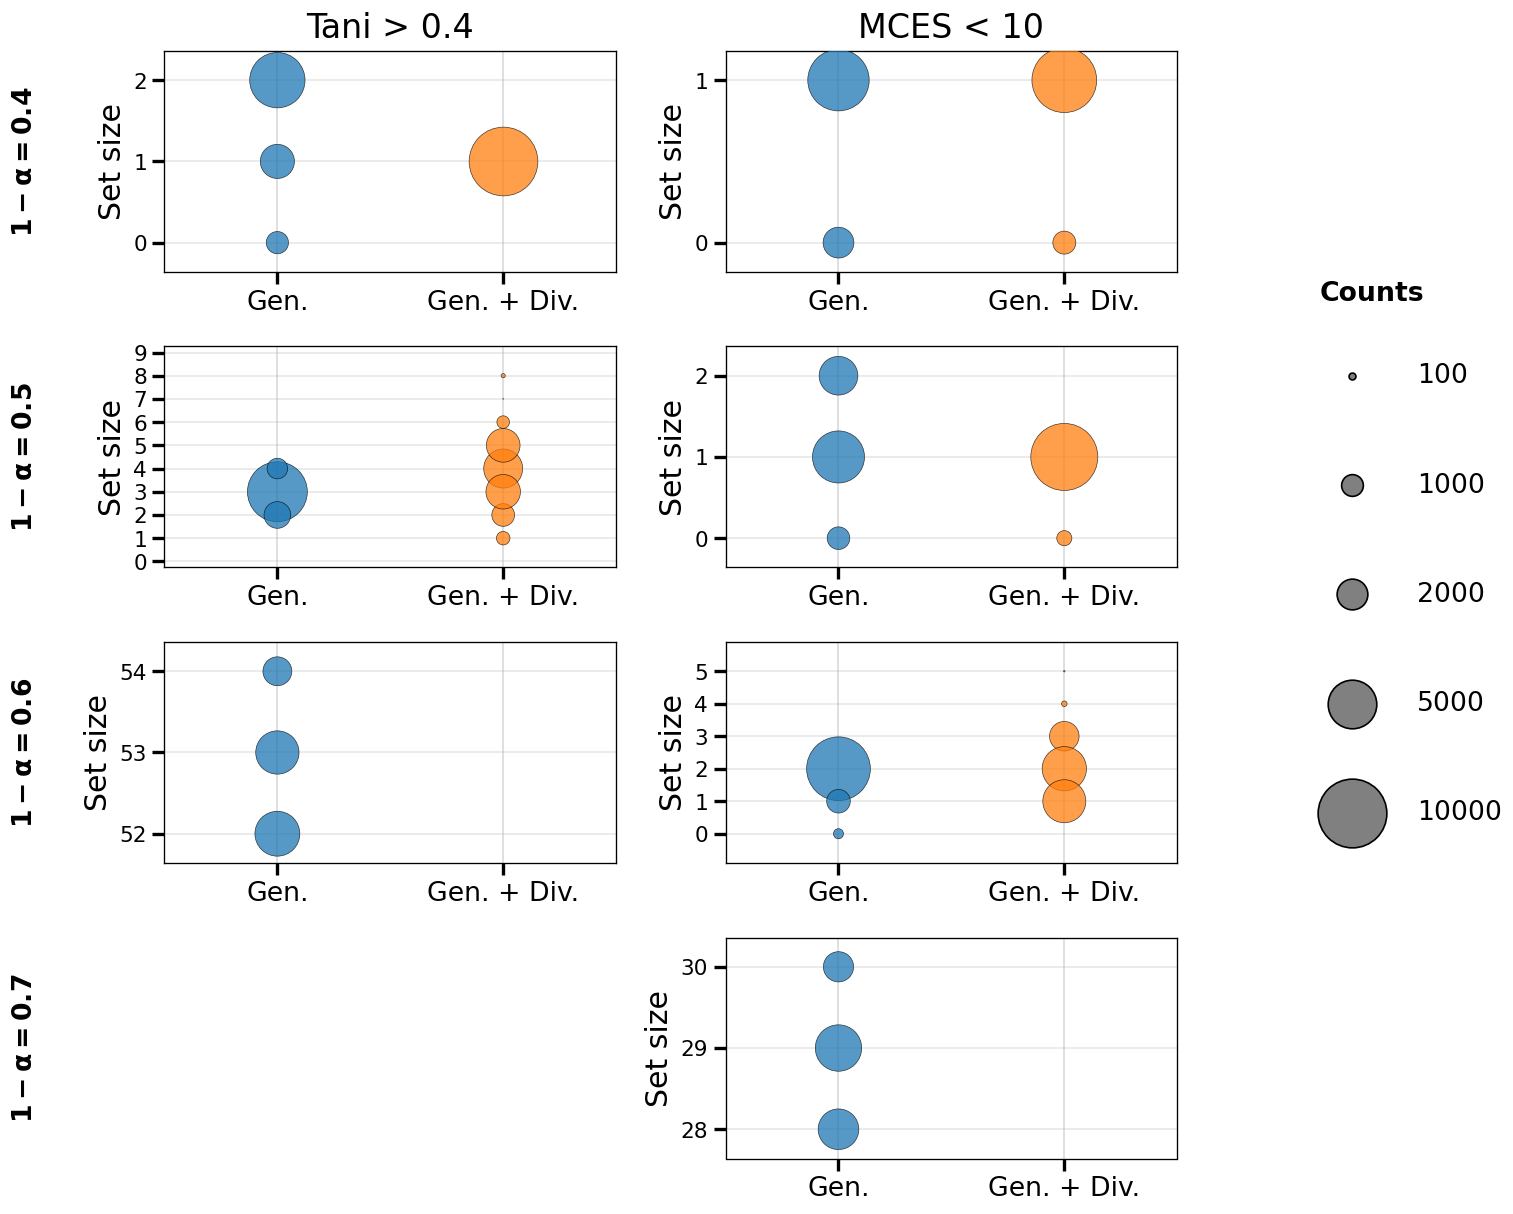

In [72]:
plot_dot_matrix(filtered)

### Set Size vs Parent Mass

In [56]:
def flatten_gt_masses(gt_masses):
    out = []
    if not gt_masses:
        return out
    for group in gt_masses:
        if isinstance(group, (list, tuple, np.ndarray)):
            for v in group:
                try:
                    out.append(float(v))
                except Exception:
                    pass
    return out

def plot_quantile_binned_mean_trends(filtered):
    slices = [
        ("tani", 0.4, 0.5, "Tani > 0.4"),
        ("mces", 10, 0.4, "MCES < 10"),
    ]
    methods = [("gen-only", "Gen."), ("gen", "Gen. + Div.")]
    colors = {"gen-only": "#1f77b4", "gen": "#ff7f0e"}
    n_bins = 8
    from matplotlib.gridspec import GridSpec
    fig = plt.figure(figsize=(12, 6), constrained_layout=False)
    gs = GridSpec(2, 2, height_ratios=[1, 4], wspace=0.18, hspace=0.20)
    axes = np.empty((2, 2), dtype=object)
    for col in range(2):
        axes[0, col] = fig.add_subplot(gs[0, col])
        axes[1, col] = fig.add_subplot(gs[1, col], sharex=axes[0, col])

    for i, (score_type, param, alpha_disp, label) in enumerate(slices):
        this_alpha = np.round(1 - alpha_disp, 2)
        for method, method_label in methods:
            xs_all, ys_all, xs_fr_all, ys_fr_all = [], [], [], []
            for r in filtered:
                if not (r.get("score") == "sum"
                        and str(r.get("score_type")) == score_type
                        and np.isclose(float(r.get("param", -999)), param)
                        and str(r.get("method")) == method
                        and np.isclose(np.round(1 - float(r.get("alpha")), 2), this_alpha)):
                    continue
                gt = flatten_gt_masses(r.get("gt_masses", []))
                seen = np.array(r.get("seen_size_list", []), dtype=float)
                unseen = np.array(r.get("unseen_size_list", []), dtype=float)
                set_sizes = np.concatenate([seen, unseen]) if len(unseen) and np.any(unseen > 0) else seen
                set_sizes = set_sizes[np.isfinite(set_sizes)]
                mask_nonzero = set_sizes > 0
                gt_nonzero = np.array(gt)[mask_nonzero] if len(gt) == len(set_sizes) else np.array(gt)
                set_sizes_nonzero = set_sizes[mask_nonzero]
                n = min(len(gt_nonzero), len(set_sizes_nonzero))
                if n > 0:
                    xs_all.extend(gt_nonzero[:n])
                    ys_all.extend(set_sizes_nonzero[:n])
                n_fr = min(len(gt), len(set_sizes))
                if n_fr > 0:
                    xs_fr_all.extend(gt[:n_fr])
                    ys_fr_all.extend(set_sizes[:n_fr])
            xs_all, ys_all = np.array(xs_all), np.array(ys_all)
            xs_fr_all, ys_fr_all = np.array(xs_fr_all), np.array(ys_fr_all)
            if len(xs_all) > 0 and len(xs_fr_all) > 0:
                bin_edges = np.quantile(xs_fr_all, np.linspace(0, 1, n_bins+1))
                bx, by, bxfr, byfr = [], [], [], []
                for k in range(n_bins):
                    mask = (xs_all >= bin_edges[k]) & (xs_all < bin_edges[k+1])
                    if np.sum(mask) > 5:
                        bx.append(np.mean(xs_all[mask]))
                        by.append(np.mean(ys_all[mask]))
                    mask_fr = (xs_fr_all >= bin_edges[k]) & (xs_fr_all < bin_edges[k+1])
                    bin_den = np.sum(mask_fr)
                    if bin_den > 5:
                        bin_num = np.sum(ys_fr_all[mask_fr] == 0)
                        bxfr.append(np.mean(xs_fr_all[mask_fr]))
                        byfr.append(bin_num / bin_den)
                axes[0, i].plot(bxfr, byfr, marker="o", linewidth=2, color=colors[method], label=method_label)
                axes[1, i].plot(bx, by, marker="o", linewidth=2, color=colors[method], label=method_label)

        axes[0, i].set_title(f"{label}\n$1-\\alpha={this_alpha}$")
        axes[0, i].set_ylim(-0.01, 0.1)
        axes[1, i].set_ylabel("Average Set Size" if i == 0 else "")
        axes[0, i].set_ylabel("Fraction\nRejected" if i == 0 else "")
        axes[1, i].set_xlabel("Parent Mass")
        axes[0, i].set_xticklabels([])
        axes[0, i].grid(alpha=0.3)
        axes[1, i].grid(alpha=0.3)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles, labels, loc="lower center", bbox_to_anchor=(0.5, -0.03),
        ncol=len(methods), frameon=False
    )

    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.savefig("quantile_binned_trends.svg", format="svg", bbox_inches="tight", pad_inches=0.3)
    plt.show()

In [ ]:
plot_quantile_binned_mean_trends(filtered)

### Mass Bins

In [58]:
def safe_array(x):
    if x is None:
        return np.array([])
    if isinstance(x, (list, tuple, np.ndarray)):
        return np.array(x, dtype=float)
    return np.array([x], dtype=float)

def clean_mean(x):
    x = np.array(x, dtype=float)
    x = x[np.isfinite(x) & (x > 0)]  # Exclude zeros & nonfinite
    return np.mean(x) if len(x) else np.nan

def load_pickle(path):
    with open(path, "rb") as f:
        d = pickle.load(f)
    coverages, sizes, mass_bins = d["coverages"], d["sizes"], d["mass_bins"]
    from collections import defaultdict
    bin_seen_size = defaultdict(list); bin_unseen_size = defaultdict(list)
    bin_seen_cov = defaultdict(list); bin_unseen_cov = defaultdict(list)
    bin_seen_rejected_cnt = defaultdict(int); bin_seen_total_cnt = defaultdict(int)
    bin_unseen_rejected_cnt = defaultdict(int); bin_unseen_total_cnt = defaultdict(int)

    for i, bin_info in enumerate(mass_bins):
        b = bin_info["bin_id"]
        c_seen, c_unseen = coverages[i]
        s_seen, s_unseen = sizes[i]
        c_seen_val, c_unseen_val = clean_mean(c_seen), clean_mean(c_unseen)
        s_seen_val, s_unseen_val = clean_mean(s_seen), clean_mean(s_unseen)
        if not (np.isfinite(s_seen_val) or np.isfinite(s_unseen_val)):
            continue
        bin_seen_cov[b].append(c_seen_val); bin_unseen_cov[b].append(c_unseen_val)
        bin_seen_size[b].append(s_seen_val); bin_unseen_size[b].append(s_unseen_val)
        arr_seen = np.array(s_seen, dtype=float); arr_seen = arr_seen[np.isfinite(arr_seen)]
        arr_unseen = np.array(s_unseen, dtype=float); arr_unseen = arr_unseen[np.isfinite(arr_unseen)]
        bin_seen_rejected_cnt[b] += np.sum(arr_seen == 0); bin_seen_total_cnt[b] += arr_seen.size
        bin_unseen_rejected_cnt[b] += np.sum(arr_unseen == 0); bin_unseen_total_cnt[b] += arr_unseen.size

    bins_sorted = sorted(set(bin_seen_size) | set(bin_unseen_size))
    return {
        "bin_ids": np.array(bins_sorted),
        "mean_seen_cov": np.array([np.nanmean(bin_seen_cov[b]) for b in bins_sorted]),
        "mean_unseen_cov": np.array([np.nanmean(bin_unseen_cov[b]) for b in bins_sorted]),
        "mean_seen_size": np.array([np.nanmean(bin_seen_size[b]) for b in bins_sorted]),
        "mean_unseen_size": np.array([np.nanmean(bin_unseen_size[b]) for b in bins_sorted]),
        "frac_rejected_seen": np.array([
            bin_seen_rejected_cnt[b]/bin_seen_total_cnt[b] if bin_seen_total_cnt[b] else np.nan
            for b in bins_sorted
        ]),
        "frac_rejected_unseen": np.array([
            bin_unseen_rejected_cnt[b]/bin_unseen_total_cnt[b] if bin_unseen_total_cnt[b] else np.nan
            for b in bins_sorted
        ]),
    }

records = []
for root in ROOTS:
    for subdir, _, files in os.walk(root):
        for f in files:
            if f.endswith(".pkl"):
                full = os.path.join(subdir, f)
                meta = parse_file(full)
                if meta is not None:
                    stats = load_pickle(full)
                    records.append({**enrich_name(meta), **stats})

/tmp/ipykernel_765532/1958571819.py:42: RuntimeWarning: Mean of empty slice
  "mean_unseen_cov": np.array([np.nanmean(bin_unseen_cov[b]) for b in bins_sorted]),
/tmp/ipykernel_765532/1958571819.py:44: RuntimeWarning: Mean of empty slice
  "mean_unseen_size": np.array([np.nanmean(bin_unseen_size[b]) for b in bins_sorted]),


/tmp/ipykernel_765532/1044449500.py:197: RuntimeWarning: Mean of empty slice
  v = float(np.nanmean(vals))


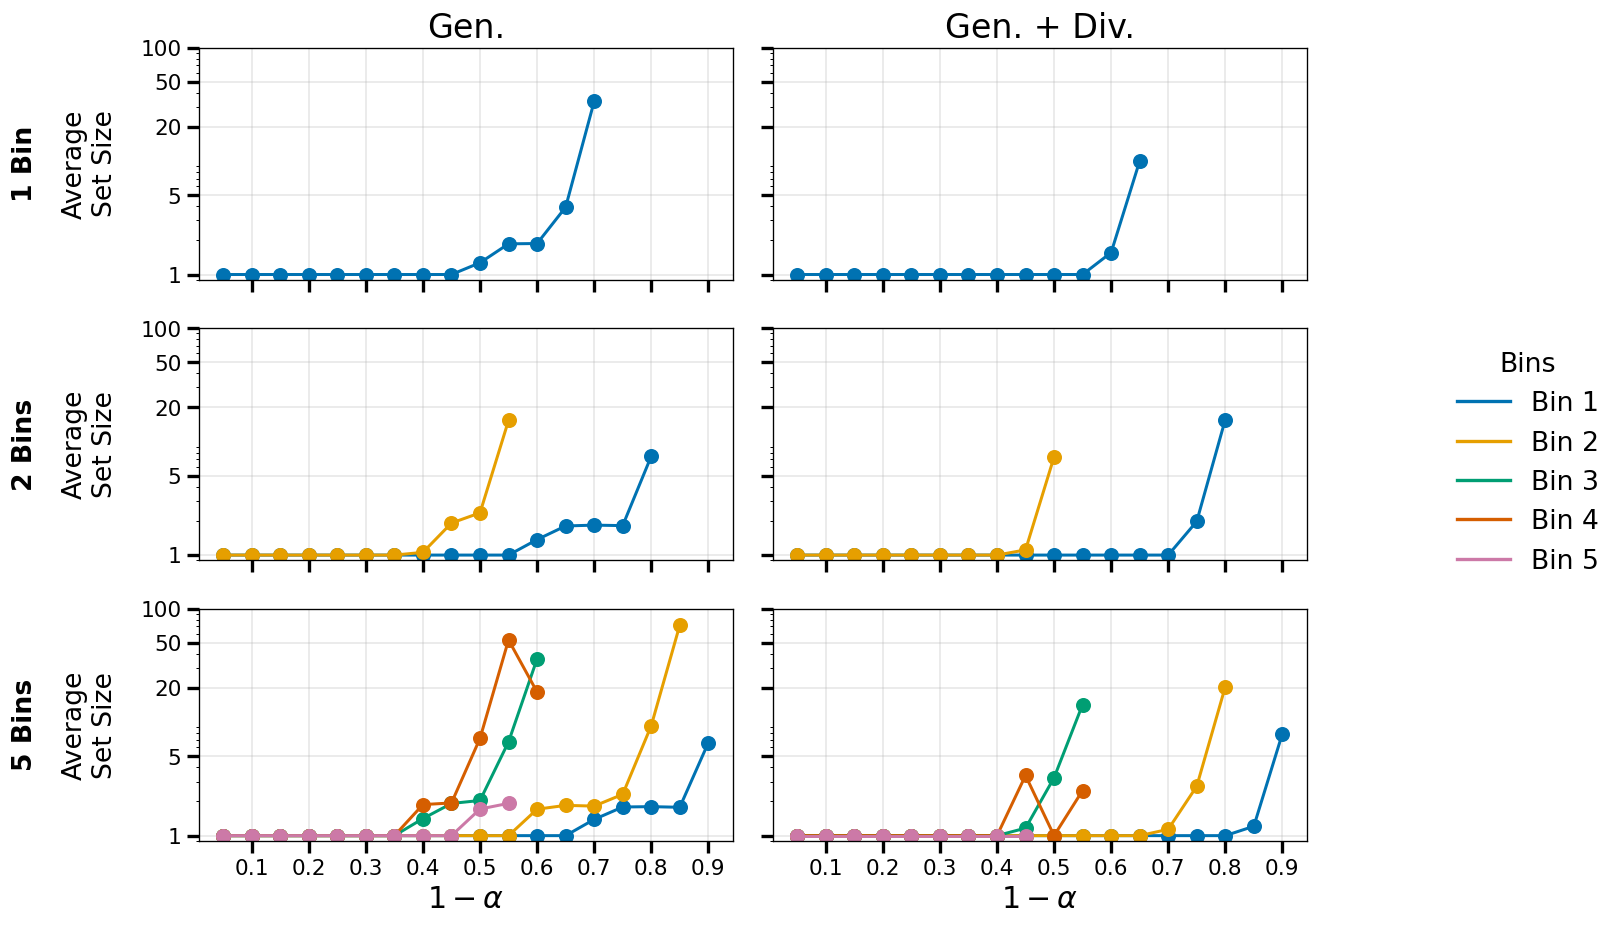

In [60]:
def compare_bins(bval, b):
    try:
        return int(float(bval)) == int(b)
    except Exception:
        print(f"DEBUG: compare_bins failed for bval={bval} (type={type(bval)}), target={b}")
        return False

def plot_structured_records(records, score_type):
    if score_type not in ["tani", "mces"]:
        raise ValueError("score_type must be 'tani' or 'mces'")

    # Show only the first three bins
    bins_list = [1, 2, 5]
    methods = [
        ("gen-only", "Gen"),
        ("gen", "Gen + Div")
    ]

    xticks = np.arange(0.1, 1.0, 0.1)
    bin_colors = [
        "#0072B2", "#E69F00", "#009E73", "#D55E00",
        "#CC79A7", "#56B4E9", "#F0E442", "#000000",
        "#999999", "#A6761D",
    ]

    fig, axes = plt.subplots(
        nrows=len(bins_list),
        ncols=2,
        figsize=(12, 8),
        sharex=True,
        sharey=True
    )

    BIN_X = -0.06
    AVG_X = -0.015
    LEGEND_X = 1.05

    for row_idx, b in enumerate(bins_list):
        for col_idx, (method, title) in enumerate(methods):
            ax = axes[row_idx, col_idx]

            # Scenario 2 panel filtering (putting all conditions here!)
            panel = []
            for r in records:
                if not compare_bins(r.get("bins", -1), b):
                    continue
                if str(r.get("score_type")) != score_type:
                    continue
                if str(r.get("method")) != method:
                    continue
                if str(r.get("score")) != "sum":
                    continue

                param = r.get("param", None)
                name = str(r.get("name", ""))

                valid = False
                if score_type == "tani":
                    valid = np.isclose(float(param), 0.4)
                elif score_type == "mces":
                    valid = (int(float(param)) == 10) and ("mces1" in name)
                if not valid:
                    continue

                panel.append(r)

            if not panel:
                ax.set_axis_off()
                continue

            bin_store = defaultdict(lambda: defaultdict(list))

            for r in panel:
                alpha = round(1.0 - float(r["alpha"]), 10)
                vals = np.atleast_1d(np.asarray(r["mean_seen_size"], dtype=float))

                # 1-bin (scalar or length-1 vector)
                if b == 1:
                    v = float(np.nanmean(vals))
                    if np.isfinite(v):      # <--- INCLUDE mean==1 now
                        bin_store[0][alpha].append(v)
                    continue

                # Multi-bin case
                for bin_id, v in enumerate(vals):
                    if np.isfinite(v):      # <--- INCLUDE mean==1 now
                        bin_store[bin_id][alpha].append(v)

            for bin_id in sorted(bin_store.keys()):
                xs = sorted(bin_store[bin_id].keys())
                xvals, yvals = [], []
                for x in xs:
                    vals = bin_store[bin_id][x]
                    if len(vals) == 0:
                        continue
                    xvals.append(x)
                    yvals.append(np.nanmean(vals))
                if len(xvals) == 0:
                    continue
                ax.plot(
                    xvals,
                    yvals,
                    marker="o",
                    color=bin_colors[bin_id],
                    linewidth=1.8
                )

            ax.set_xticks(xticks)
            ax.set_yscale("log")
            ax.set_ylim(0.9, 100)
            ax.set_yticks([1, 5, 20, 50, 100])
            ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())

            ax.grid(True, which="major", alpha=0.25)
            ax.grid(False, which="minor")

            if row_idx == len(bins_list) - 1:
                ax.set_xlabel(r"$1 - \alpha$")
            if row_idx == 0:
                ax.set_title(title)

    plt.tight_layout(rect=[0, 0, 0.85, 1])
    fig.canvas.draw()

    for row_idx, b in enumerate(bins_list):
        bbox = axes[row_idx, 0].get_position()
        y_center = (bbox.y0 + bbox.y1) / 2
        fig.text(
            BIN_X, y_center, f"{b} Bin" + ("s" if b > 1 else ""),
            rotation=90, fontweight="bold", va="center", ha="center"
        )
        fig.text(
            AVG_X, y_center, "Average\nSet Size",   # <--- use "Average"
            rotation=90, va="center", ha="center"
        )

    # Show only legend for the max needed bins (here, up to 5 bins)
    legend_handles = [
        Line2D([0], [0],
               color=bin_colors[i],
               lw=2,
               label=f"Bin {i+1}")
        for i in range(max(bins_list))
    ]
    fig.legend(
        handles=legend_handles,
        loc="center right",
        bbox_to_anchor=(LEGEND_X, 0.5),
        frameon=False,
        title="Bins"
    )
    plt.show()
def compare_bins(bval, b):
    try:
        return int(float(bval)) == int(b)
    except Exception:
        return False

def plot_structured_records(records, score_type):
    if score_type not in ["tani", "mces"]:
        raise ValueError("score_type must be 'tani' or 'mces'")
    bins_list = [1, 2, 5]
    methods = [("gen-only", "Gen."), ("gen", "Gen. + Div.")]
    xticks = np.arange(0.1, 1.0, 0.1)
    bin_colors = [
        "#0072B2", "#E69F00", "#009E73", "#D55E00",
        "#CC79A7", "#56B4E9", "#F0E442", "#000000",
        "#999999", "#A6761D",
    ]
    fig, axes = plt.subplots(
        nrows=len(bins_list), ncols=2, figsize=(12, 8), sharex=True, sharey=True
    )
    BIN_X, AVG_X, LEGEND_X = -0.06, -0.015, 1.05

    for row_idx, b in enumerate(bins_list):
        for col_idx, (method, title) in enumerate(methods):
            ax = axes[row_idx, col_idx]
            panel = [
                r for r in records
                if compare_bins(r.get("bins", -1), b)
                and str(r.get("score_type")) == score_type
                and str(r.get("method")) == method
                and str(r.get("score")) == "sum"
                and (
                    (score_type == "tani" and np.isclose(float(r.get("param", 0)), 0.4)) or
                    (score_type == "mces" and int(float(r.get("param", -1))) == 10 and "mces1" in str(r.get("name", "")))
                )
            ]
            if not panel:
                ax.set_axis_off()
                continue
            bin_store = defaultdict(lambda: defaultdict(list))
            for r in panel:
                alpha = round(1.0 - float(r["alpha"]), 10)
                vals = np.atleast_1d(np.asarray(r["mean_seen_size"], dtype=float))
                if b == 1:
                    v = float(np.nanmean(vals))
                    if np.isfinite(v):
                        bin_store[0][alpha].append(v)
                else:
                    for bin_id, v in enumerate(vals):
                        if np.isfinite(v):
                            bin_store[bin_id][alpha].append(v)
            for bin_id in sorted(bin_store):
                xs = sorted(bin_store[bin_id].keys())
                xvals = [x for x in xs if bin_store[bin_id][x]]
                yvals = [np.nanmean(bin_store[bin_id][x]) for x in xvals]
                if xvals:
                    ax.plot(xvals, yvals, marker="o", color=bin_colors[bin_id], linewidth=1.8)
            ax.set_xticks(xticks)
            ax.set_yscale("log")
            ax.set_ylim(0.9, 100)
            ax.set_yticks([1, 5, 20, 50, 100])
            ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())
            ax.grid(True, which="major", alpha=0.25)
            ax.grid(False, which="minor")
            if row_idx == len(bins_list) - 1:
                ax.set_xlabel(r"$1 - \alpha$")
            if row_idx == 0:
                ax.set_title(title)

    plt.tight_layout(rect=[0, 0, 0.85, 1])
    fig.canvas.draw()
    for row_idx, b in enumerate(bins_list):
        bbox = axes[row_idx, 0].get_position()
        y_center = (bbox.y0 + bbox.y1) / 2
        fig.text(BIN_X, y_center, f"{b} Bin" + ("s" if b > 1 else ""), rotation=90, fontweight="bold", va="center", ha="center")
        fig.text(AVG_X, y_center, "Average\nSet Size", rotation=90, va="center", ha="center")
    legend_handles = [
        Line2D([0], [0], color=bin_colors[i], lw=2, label=f"Bin {i+1}")
        for i in range(max(bins_list))
    ]
    fig.legend(
        handles=legend_handles, loc="center right", bbox_to_anchor=(LEGEND_X, 0.5),
        frameon=False, title="Bins"
    )
    plt.savefig("structured_bins.svg", format="svg", bbox_inches="tight")
    plt.show()
plot_structured_records(records, "mces")

### Qualitative results

In [ ]:
import os
import pickle
import json
import pandas as pd
import random
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
from rdkit.Chem.Draw import rdMolDraw2D

base_dir = "scope_gen/de_novo_molecules/data/finetune-mces1/beam100/eval_results"
N_SHOW = 3

paths = {
    'mces_gen': os.path.join(base_dir, "SCOPE-gen-only_mces_10_mces1/SCOPE-gen-only_mces_10_mces1_sum1_04.pkl"),
    'mces_gen_div': os.path.join(base_dir, "SCOPE-gen_mces_10_mces1/SCOPE-gen_mces_10_mces1_sum1_04.pkl"),
    'tani_gen': os.path.join(base_dir, "SCOPE-gen-only_tani_0.4_mces1/SCOPE-gen-only_tani_0.4_mces1_sum1_05.pkl"),
    'tani_gen_div': os.path.join(base_dir, "SCOPE-gen_tani_0.4_mces1/SCOPE-gen_tani_0.4_mces1_sum1_05.pkl"),
}

results = {k: pickle.load(open(v, "rb")) for k, v in paths.items()}
labels_df = pd.read_csv("scope_gen/de_novo_molecules/data/finetune-mces1/beam100/labels.tsv", sep="\t")
samples = [json.loads(line) for line in open("scope_gen/de_novo_molecules/data/finetune-mces1/beam100/samples.jsonl")]

from myopic_mces import MCES

def get_seen_dict(res):
    return res["set_positions_data_idx"][0][0]

def random_indices(seen_dict_gen, seen_dict_div, N):
    valid = list(set(seen_dict_gen.keys()) & set(seen_dict_div.keys()))
    return random.sample(valid, min(N, len(valid)))

def mces_distance(smiles1, smiles2, return_type="distance"):
    res = MCES(smiles1, smiles2)
    if isinstance(res, tuple):
        mces_size, mces_dist, runtime, meta = res
        if return_type == "size":
            return float(mces_size)
        if return_type == "distance":
            return float(mces_dist)
        if return_type == "time":
            return float(runtime)
        return res
    return float(res)

def mol_to_svg(mol, size=(180,180)):
    d2d = rdMolDraw2D.MolDraw2DSVG(size[0], size[1])
    d2d.DrawMolecule(mol)
    d2d.FinishDrawing()
    svg = d2d.GetDrawingText()
    start = svg.find('<svg')
    stop = svg.rfind('</svg>')
    return svg[start:stop+6]

def extract_svg_content(svg):
    start = svg.find('<svg')
    stop = svg.rfind('</svg>')
    return svg[start + svg[start:].find('>') + 1:stop]

def get_data(mode, N, preds_max):
    gen_key, div_key = f"{mode}_gen", f"{mode}_gen_div"
    seen_dict_gen = get_seen_dict(results[gen_key])
    seen_dict_div = get_seen_dict(results[div_key])
    indices = random_indices(seen_dict_gen, seen_dict_div, N)
    data = []
    for idx in indices:
        gt_smiles = labels_df.iloc[idx]["SMILES"]
        gt_mol = Chem.MolFromSmiles(gt_smiles)
        gt_fp = AllChem.GetMorganFingerprintAsBitVect(gt_mol, radius=2, nBits=2048)
        gen_preds = []
        for pred_idx in list(seen_dict_gen[idx])[:preds_max]:
            smi = samples[idx]["pred"][pred_idx]
            mol = Chem.MolFromSmiles(smi)
            if mol:
                fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
                tani = DataStructs.TanimotoSimilarity(gt_fp, fp)
                mces = mces_distance(gt_smiles, smi, return_type="distance")
                gen_preds.append((mol, tani, mces))
        div_preds = []
        for pred_idx in list(seen_dict_div[idx])[:preds_max]:
            smi = samples[idx]["pred"][pred_idx]
            mol = Chem.MolFromSmiles(smi)
            if mol:
                fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=2048)
                tani = DataStructs.TanimotoSimilarity(gt_fp, fp)
                mces = mces_distance(gt_smiles, smi, return_type="distance")
                div_preds.append((mol, tani, mces))
        data.append({"gt_mol": gt_mol, "gen_preds": gen_preds, "div_preds": div_preds})
    return data

def compose_svg(
    data,
    mol_size=(180,180),
    xpad=40,
    y0=24,
    block_vpad=16,
    block_hpad=15,
    label_font=30,
    method_font=32,
    metric_font=23,  
    black_line_width=4,
    preds_max=4
):
    GT_x = xpad
    sep_x = GT_x + mol_size[0] + xpad // 2
    pred_start_x = sep_x + black_line_width + xpad // 2

    metric_block = metric_font * 2 + 20
    row_height = mol_size[1] + method_font + metric_block + block_vpad + 6
    fig_height = len(data) * (2*row_height) + y0
    fig_width = pred_start_x + (mol_size[0]+block_hpad)*preds_max + xpad

    svg = [f'<svg width="{fig_width}" height="{fig_height}" xmlns="http://www.w3.org/2000/svg">']
    svg.append(f'<rect width="{fig_width}" height="{fig_height}" fill="white"/>')

    for d, row in enumerate(data):
        gt_svg = mol_to_svg(row["gt_mol"], mol_size)
        gt_y = y0 + d*2*row_height
        GT_block_height = 2*row_height

        # Short vertical black line for this GT block
        svg.append(f'<rect x="{sep_x}" y="{gt_y}" width="{black_line_width}" height="{GT_block_height}" fill="black" />')

        # Ground Truth: centered for the block (occupies both rows' height)
        gt_y_span = gt_y + (GT_block_height - mol_size[1])//2
        svg.append(f'<g transform="translate({GT_x},{gt_y_span})">{extract_svg_content(gt_svg)}</g>')
        svg.append(f'<text x="{GT_x+mol_size[0]/2}" y="{gt_y_span + mol_size[1] + label_font + 8}" text-anchor="middle" '
                   f'style="font-size:{label_font}px;font-family:sans-serif;">Ground Truth</text>')

        # --- Top Row: Gen.
        y_top = gt_y
        svg.append(f'<text x="{pred_start_x + (mol_size[0]+block_hpad)*preds_max/2}" '
                   f'y="{y_top+method_font}" text-anchor="middle" '
                   f'style="font-size:{method_font}px;font-family:sans-serif;">Gen.</text>')
        for j, (mol, tani, mces) in enumerate(row["gen_preds"][:preds_max]):
            x_pred = pred_start_x + j*(mol_size[0]+block_hpad)
            mol_svg = mol_to_svg(mol, mol_size)
            y_mol = y_top + method_font
            svg.append(f'<g transform="translate({x_pred},{y_mol})">{extract_svg_content(mol_svg)}</g>')
            svg.append(f'<text x="{x_pred+mol_size[0]/2}" y="{y_mol+mol_size[1]+metric_font+10}" '
                       f'text-anchor="middle" style="font-size:{metric_font}px;font-family:sans-serif;" fill="black">MCES: {mces:.2f}</text>')
            svg.append(f'<text x="{x_pred+mol_size[0]/2}" y="{y_mol+mol_size[1]+metric_font*2+22}" '
                       f'text-anchor="middle" style="font-size:{metric_font}px;font-family:sans-serif;" fill="black">Tani: {tani:.2f}</text>')

        # --- Bottom Row: Gen.+Div.
        y_bot = gt_y + row_height
        svg.append(f'<text x="{pred_start_x + (mol_size[0]+block_hpad)*preds_max/2}" '
                   f'y="{y_bot+method_font}" text-anchor="middle" '
                   f'style="font-size:{method_font}px;font-family:sans-serif;">Gen. + Div.</text>')
        for j, (mol, tani, mces) in enumerate(row["div_preds"][:preds_max]):
            x_pred = pred_start_x + j*(mol_size[0]+block_hpad)
            mol_svg = mol_to_svg(mol, mol_size)
            y_mol = y_bot + method_font
            svg.append(f'<g transform="translate({x_pred},{y_mol})">{extract_svg_content(mol_svg)}</g>')
            svg.append(f'<text x="{x_pred+mol_size[0]/2}" y="{y_mol+mol_size[1]+metric_font+10}" '
                       f'text-anchor="middle" style="font-size:{metric_font}px;font-family:sans-serif;" fill="black">MCES: {mces:.2f}</text>')
            svg.append(f'<text x="{x_pred+mol_size[0]/2}" y="{y_mol+mol_size[1]+metric_font*2+22}" '
                       f'text-anchor="middle" style="font-size:{metric_font}px;font-family:sans-serif;" fill="black">Tani: {tani:.2f}</text>')

    svg.append('</svg>')
    return ''.join(svg)

for mode, preds_max in [('mces', 4), ('tani', 4)]:
    data = get_data(mode, N_SHOW, preds_max)
    svg = compose_svg(
        data,
        mol_size=(300,300), xpad=48, y0=36,
        block_vpad=18, block_hpad=16, label_font=40,
        method_font=40, metric_font=30,
        black_line_width=0, preds_max=preds_max
    )
    out_name = f"figure_{mode}.svg"
    with open(out_name, "w") as f:
        f.write(svg)
    print(f"Wrote SVG output: {out_name}")

# Appendix

## A.1 MassSpecGym Stats

In [ ]:
df = pd.read_csv("MS-BART/data/MassSpecGym/MassSpecGym.tsv", sep="\t", usecols=["inchikey","parent_mass","mzs"])
c = COLORS["Other"]

spectra = df["inchikey"].value_counts()
df["n_peaks"] = df["mzs"].astype(str).str.count(",") + 1
mol_mass = df.groupby("inchikey")["parent_mass"].median()

mol_df = pd.DataFrame({
    "parent_mass": mol_mass,
    "n_spectra": spectra
}).dropna()

pm = pd.to_numeric(df["parent_mass"], errors="coerce")

# ------------------------------------------------------------
# 1) parent mass (spectra)
# ------------------------------------------------------------
plt.hist(pm.dropna(), bins=100, color=c, alpha=0.85)
plt.xlabel("Parent mass"); plt.ylabel("Number of spectra")
plt.tight_layout()
plt.savefig("parent_mass_spectra.svg")
plt.close()

# ------------------------------------------------------------
# 2) parent mass (molecules)
# ------------------------------------------------------------
plt.hist(mol_df["parent_mass"], bins=100, color=c, alpha=0.85)
plt.xlabel("Parent mass"); plt.ylabel("Number of molecules")
plt.tight_layout()
plt.savefig("parent_mass_molecules.svg")
plt.close()

# ------------------------------------------------------------
# 3) spectra per molecule
# ------------------------------------------------------------
plt.hist(
    spectra.values,
    bins=np.arange(1, spectra.max() + 5, 5),
    color=c,
    alpha=0.85
)
plt.yscale("log")
plt.xlabel("Spectra per molecule")
plt.ylabel("Number of molecules")
plt.tight_layout()
plt.savefig("spectra_per_molecule.svg")
plt.close()

# ------------------------------------------------------------
# 4) molecule frequency coverage (cumulative)
# ------------------------------------------------------------
sorted_counts = np.sort(spectra.values)[::-1]
plt.plot(np.cumsum(sorted_counts) / sorted_counts.sum(), color=c, lw=2)
plt.xlabel("Molecules (sorted by frequency)")
plt.ylabel("Cumulative fraction of spectra")
plt.tight_layout()
plt.savefig("molecule_frequency_coverage.svg")
plt.close()

# ------------------------------------------------------------
# 5) fragment peak counts
# ------------------------------------------------------------
plt.hist(df["n_peaks"].dropna(), bins=50, color=c, alpha=0.85)
plt.xlabel("Fragment peaks per spectrum")
plt.ylabel("Number of spectra")
plt.tight_layout()
plt.savefig("fragment_peak_counts.svg")
plt.close()

## A.2 APE Tokenization

In [ ]:
from importlib.machinery import SourceFileLoader

APETokenizer = SourceFileLoader(
    "ape_tokenizer",
    "MS-BART/apetokenizer/ape_tokenizer.py"
).load_module().APETokenizer

tokenizer = APETokenizer()
tokenizer.load_vocabulary("data/tokenizer/vocab.json")

INPUT_FILE = "MS-BART/data/MassSpecGym/molecules/MassSpecGym_molecules_MCES2_disjoint_with_test_fold_4M.tsv"
CHUNK_SIZE = 100_000

RAW_OUTPUT = "token_lengths.npz"
HIST_OUTPUT = "token_length_histograms.json"
SUMMARY_OUTPUT = "token_length_summary.json"

def selfies_len(s): 
    return len(list(sf.split_selfies(s)))

def stats(x):
    x = np.asarray(x)
    return {
        "count": int(len(x)),
        "min": int(x.min()),
        "max": int(x.max()),
        "mean": float(x.mean()),
        "median": float(np.median(x)),
        "p90": float(np.percentile(x, 90)),
        "p95": float(np.percentile(x, 95)),
        "p99": float(np.percentile(x, 99)),
    }

lengths = {"smiles_char": [], "selfies": [], "ape": []}
hists = {k: Counter() for k in lengths}

reader = pd.read_csv(
    INPUT_FILE,
    sep="\t",
    chunksize=CHUNK_SIZE,
    usecols=["smiles", "selfies"],
)

for chunk in tqdm(reader):
    smiles = chunk["smiles"].astype(str).tolist()
    selfies = chunk["selfies"].astype(str).tolist()

    vals = {
        "smiles_char": [len(s) for s in smiles],
        "selfies": [selfies_len(s) for s in selfies],
        "ape": [len(tokenizer.encode(s)) for s in smiles],
    }

    for k, v in vals.items():
        lengths[k].extend(v)
        hists[k].update(v)

lengths = {
    k: np.array(v, dtype=np.uint32)
    for k, v in lengths.items()
}

np.savez_compressed(RAW_OUTPUT, **lengths)

with open(HIST_OUTPUT, "w") as f:
    json.dump({k: dict(v) for k, v in hists.items()}, f)

with open(SUMMARY_OUTPUT, "w") as f:
    json.dump({k: stats(v) for k, v in lengths.items()}, f, indent=2)

data = np.load(RAW_OUTPUT)

plot_colors = [
    COLORS["Scenario 1"],
    COLORS["Scenario 2"],
    COLORS["Scenario 3"],
]

MAX_X = 150
BIN_WIDTH = 2
bins = np.arange(0, MAX_X + BIN_WIDTH, BIN_WIDTH)

fig, ax = plt.subplots()

ax.hist(
    data["smiles_char"],
    bins=bins,
    alpha=0.45,
    color=plot_colors[0],
    label="SMILES (char)",
)

ax.hist(
    data["ape"],
    bins=bins,
    alpha=0.45,
    color=plot_colors[2],
    label="SMILES (APE)",
)

ax.hist(
    data["selfies"],
    bins=bins,
    alpha=0.45,
    color=plot_colors[1],
    label="SELFIES",
)

ax.set_xlim(0, MAX_X)
ax.set_xlabel("Sequence Length")
ax.set_ylabel("Number of Molecules")
ax.ticklabel_format(axis="y", style="sci", scilimits=(5, 5))
ax.xaxis.set_major_locator(MultipleLocator(25))
ax.yaxis.set_major_locator(MultipleLocator(200000))
ax.legend()

plt.tight_layout()
plt.savefig("token_length_distributions.svg")
plt.show()

### SCOPE-gen: single Mass bin

### Scatter plots/Distributions